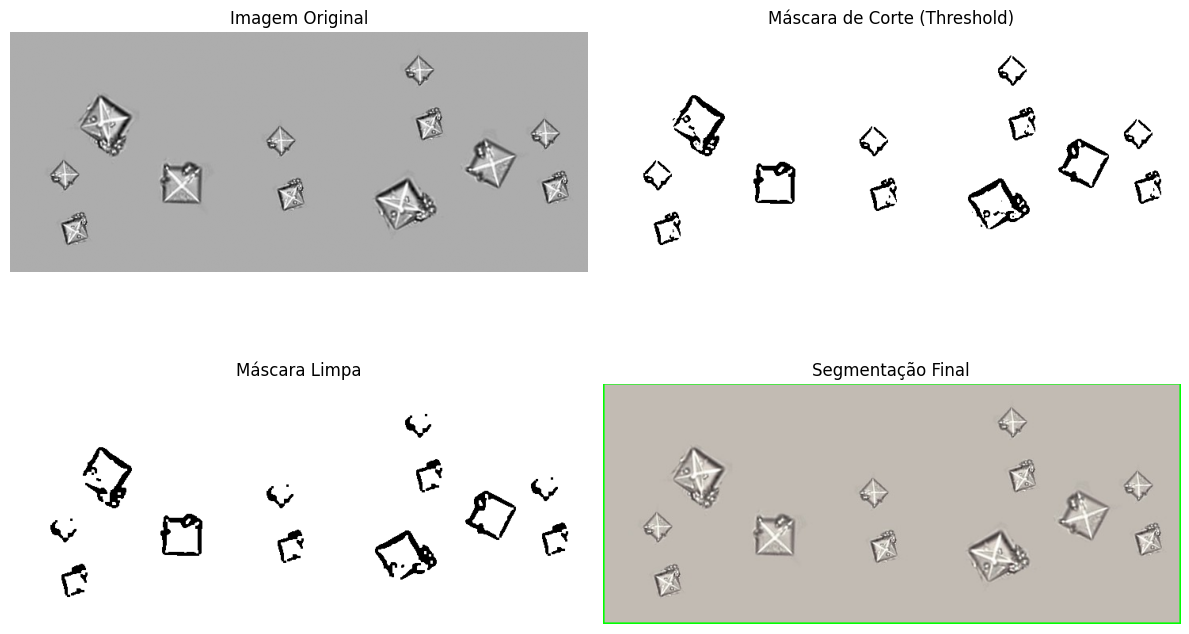

Total de objetos segmentados: 1


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar imagem (ou criar sintética para teste)
imagem = cv2.imread('ImagemTeste5.png')

imagem_colorida = imagem.copy()
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

# 2. Suavizar para reduzir ruído
imagem_suave = cv2.GaussianBlur(imagem, (5,5), 1)

# 3. Aplicar limiarização (threshold)
# Método Otsu encontra automaticamente o melhor valor de corte
_, mascara = cv2.threshold(imagem_suave, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. Limpar a máscara (remove pequenos ruídos)
kernel = np.ones((3,3), np.uint8)
mascara_limpa = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)   # Remove pontos pequenos
mascara_limpa = cv2.morphologyEx(mascara_limpa, cv2.MORPH_CLOSE, kernel)  # Fecha buracos

# 5. Encontrar contornos na máscara
contornos, _ = cv2.findContours(mascara_limpa, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 6. Desenhar contornos na imagem original
resultado = imagem_colorida.copy()
cv2.drawContours(resultado, contornos, -1, (0, 255, 0), 2)

# 7. Mostrar resultados
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(imagem, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(mascara, cmap='gray')
plt.title('Máscara de Corte (Threshold)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(mascara_limpa, cmap='gray')
plt.title('Máscara Limpa')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title('Segmentação Final')
plt.axis('off')

plt.tight_layout()
plt.show()

# Opcional: Salvar resultado
cv2.imwrite('resultado_segmentacao_corte.png', resultado)

# Extra: Contar objetos encontrados
print(f"Total de objetos segmentados: {len(contornos)}")

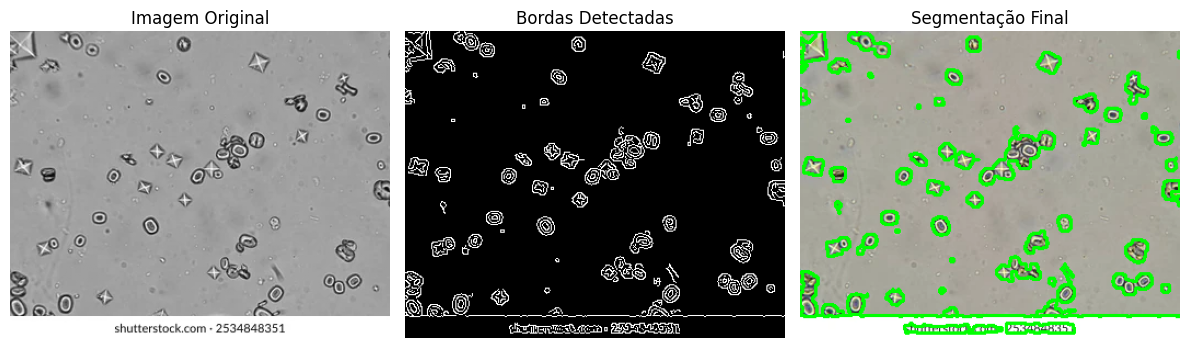

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar imagem (ou criar sintética para teste)
imagem = cv2.imread('ImagemTeste1.png')

imagem_colorida = imagem.copy()
imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

# 2. Suavizar para reduzir ruído
imagem_suave = cv2.GaussianBlur(imagem, (5,5), 1)

# 3. Detectar bordas com Canny
bordas = cv2.Canny(imagem_suave, 30, 100)

# 4. Fechar as bordas (dilatação + erosão)
kernel = np.ones((3,3), np.uint8)
bordas_fechadas = cv2.morphologyEx(bordas, cv2.MORPH_CLOSE, kernel)

# 5. Encontrar contornos
contornos, _ = cv2.findContours(bordas_fechadas, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 6. Desenhar contornos na imagem original
resultado = imagem_colorida.copy()
cv2.drawContours(resultado, contornos, -1, (0, 255, 0), 2)

# 7. Mostrar resultados
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(imagem, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(bordas, cmap='gray')
plt.title('Bordas Detectadas')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title('Segmentação Final')
plt.axis('off')

plt.tight_layout()
plt.show()